In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Exploratory Data Analysis (EDA) + Data Cleaning

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

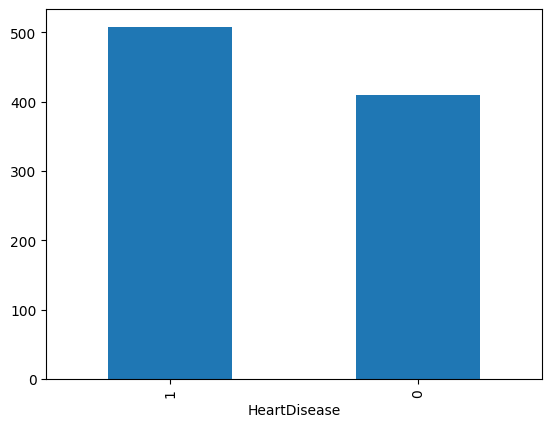

In [10]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

Numeric Data cleaning

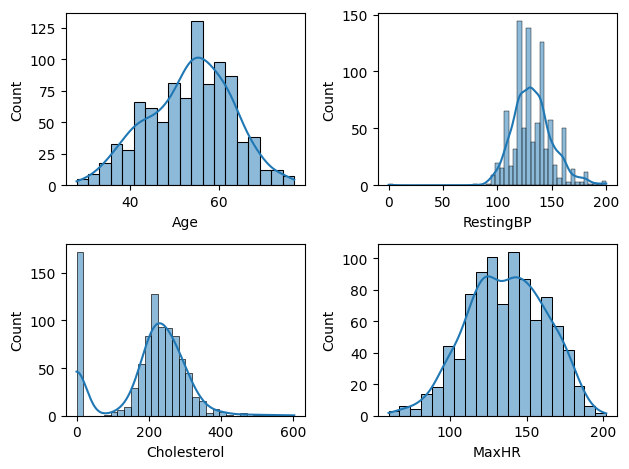

In [11]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

# Data cleaning : Invalid Cholesterol peak at 0 

In [12]:
# Cholesterol = 0 is not possible -- About 172 people in data has cholesterol = 0 which is an anomaly -- need to be cleaned (replace 0 by mean)
cholesterol_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

In [13]:
df['Cholesterol'] = df['Cholesterol'].replace(0,cholesterol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

# Data cleaning : Invalid RestingBP small peak at 0

In [14]:
# RestingBP = 0 is not possible -- need to be cleaned (replace 0 by mean)
restingBP_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()

df['RestingBP'] = df['RestingBP'].replace(0,restingBP_mean)
df['RestingBP'] = df['RestingBP'].round(2)

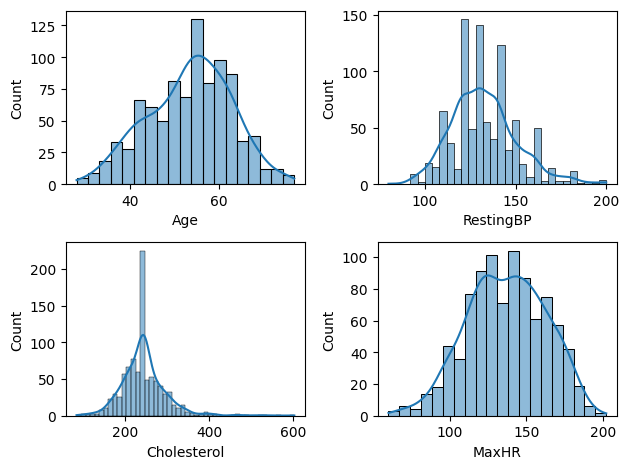

In [15]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

Categorical Data Cleaning

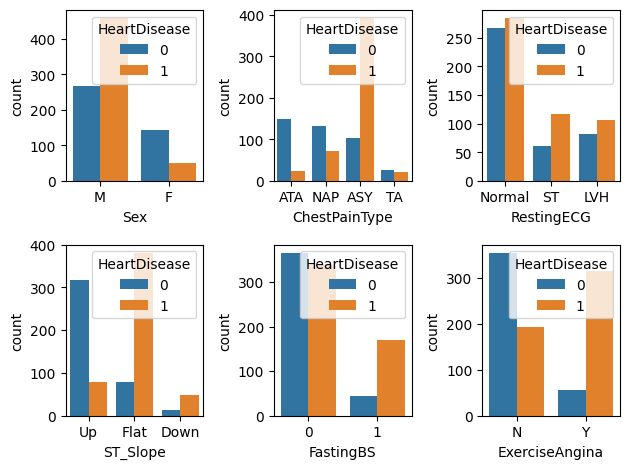

In [16]:
def count_plotting(val,num):
    plt.subplot(2,3,num)
    sns.countplot(x=df[val], hue = df['HeartDisease'])   #comparing with HeartDisease probability

count_plotting('Sex',1)
count_plotting('ChestPainType',2)
count_plotting('RestingECG',3)
count_plotting('ST_Slope',4)
count_plotting('FastingBS',5)
count_plotting('ExerciseAngina',6)

plt.tight_layout()

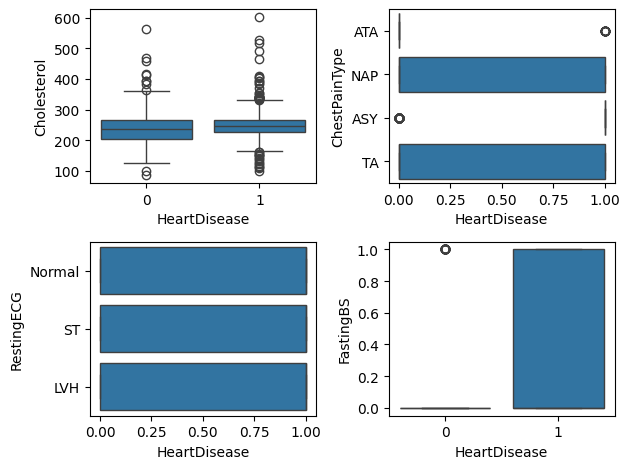

In [17]:
def count_plotting(val,num):
    plt.subplot(2,2,num)
    sns.boxplot(x='HeartDisease', y=val, data=df)

count_plotting('Cholesterol',1)
count_plotting('ChestPainType',2)
count_plotting('RestingECG',3)
count_plotting('FastingBS',4)


plt.tight_layout()

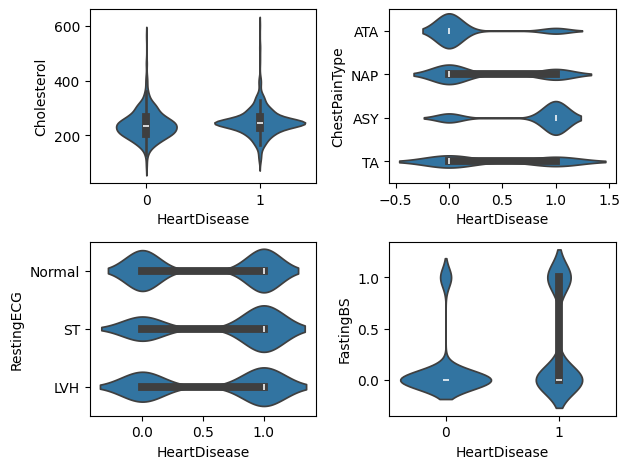

In [18]:
def count_plotting(val,num):
    plt.subplot(2,2,num)
    sns.violinplot(x='HeartDisease', y=val, data=df)

count_plotting('Cholesterol',1)
count_plotting('ChestPainType',2)
count_plotting('RestingECG',3)
count_plotting('FastingBS',4)


plt.tight_layout()

<Axes: >

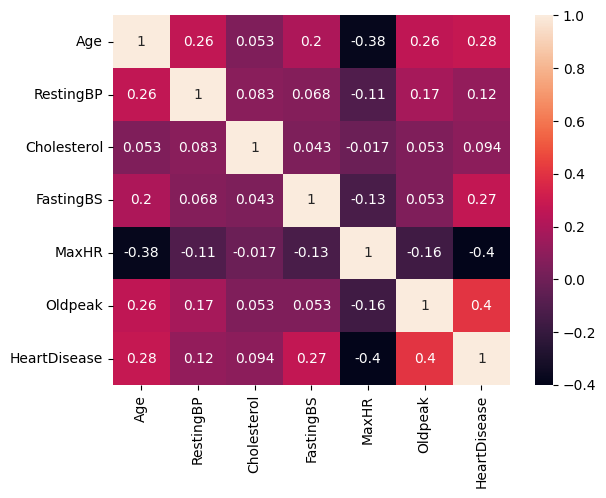

In [19]:
# HeatMap for correlation prediction
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Preprocessing

In [20]:
df_encode = pd.get_dummies(df, drop_first = True)

In [21]:
df_encode = df_encode.astype(int)

In [22]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


# Feature Engineering

In [23]:
import sys
!{sys.executable} -m pip install scikit-learn

In [24]:
from sklearn.preprocessing import StandardScaler
cols = ['Age', 'RestingBP', 'Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()

df_encode[cols] = scaler.fit_transform(df_encode[cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


# Feature Extraction

In [25]:
# for numerical data --> pearson correlation
# for categorical data --> chi-squared correlation

In [26]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [27]:
from scipy.stats import pearsonr

selected_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

correlations = {
    feature : pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns= ['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by = 'Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,Oldpeak,0.392385
0,Age,0.282039
1,RestingBP,0.117909
2,Cholesterol,0.092586
3,MaxHR,-0.400421


In [28]:
cat_features = ['FastingBS','Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

In [29]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}

for col in  cat_features:
    contingency = pd.crosstab(df_encode[col], df_encode['HeartDisease'])
    chi2_stats, p_val, _, _= chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistics' : chi2_stats,
        'p_value' : p_val,
        'Decision' :decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistics,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
Sex_M,84.145101,0.0,Reject Null (Keep Feature)
FastingBS,64.320679,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (Keep Feature)
ChestPainType_TA,2.273802,0.131577,Accept Null (Drop Feature)


In [30]:
final_df = df_encode[['Age', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']]

In [31]:
final_df.head()

,Age,MaxHR,Oldpeak,FastingBS,Sex_M,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1.382928,-0.727592,0,1,1,0,1,0,0,0,1
1,-0.478484,0.754157,0.282891,0,0,0,1,1,0,0,1,0
2,-1.751359,-1.525138,-0.727592,0,1,1,0,0,1,0,0,1
3,-0.584556,-1.132156,0.282891,0,0,0,0,1,0,1,1,0
4,0.051881,-0.581981,-0.727592,0,1,0,1,1,0,0,0,1


Feature selection note: `RestingBP` and `Cholesterol` are dropped here on Pearson correlation alone (0.12 / 0.09), and `ChestPainType_TA` on chi-squared p=0.13. Worth flagging — linear/independence tests can miss signal that a nonlinear model (RF/XGBoost) would still pick up. Kept as-is to match the analysis above; if RF/XGBoost underperform Logistic Regression later, this is the first thing worth revisiting.

# Model Training & Evaluation

## Rebuilding unscaled features for modeling
`df_encode` was scaled in-place on the *full* dataset (cell above, pre-split) — fine for the correlation/chi2 EDA above, but scaling before the train/test split leaks test-set distribution into training. Rebuilding the same `final_df` columns from unscaled data here, then splitting first and scaling only on the training fold inside a pipeline.

In [32]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, brier_score_loss)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import joblib, json, os

RANDOM_STATE = 42

In [33]:
df_model_raw = pd.get_dummies(df, drop_first=True).astype(int)

feature_cols = ['Age', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
                 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
numeric_cols = ['Age', 'MaxHR', 'Oldpeak']  

X = df_model_raw[feature_cols].copy()
y = df_model_raw['HeartDisease'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(734, 12) (184, 12)
0.553133514986376 0.5543478260869565


In [34]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
], remainder="passthrough")

Target is roughly balanced (~55% / 45%) — `class_weight="balanced"` used mainly for robustness, not because imbalance is severe.

## Model Training

### Logistic Regression

In [35]:
log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])
log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_test)
proba = log_reg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.9295791487326638 | PR-AUC: 0.9381650361779782


### KNN

In [36]:
knn = Pipeline([
    ("prep", preprocessor),
    ("clf", KNeighborsClassifier(n_neighbors=9))
])
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
proba = knn.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85        82
           1       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC-AUC: 0.9249760879961741 | PR-AUC: 0.9157854353503194


### Random Forest

In [37]:
rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=1))
])
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        82
           1       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184

ROC-AUC: 0.9146939263510282 | PR-AUC: 0.9100654220766734


### XGBoost

In [38]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=scale_pos_weight,
                           eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1))
])
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
proba = xgb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba), "| PR-AUC:", average_precision_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84        82
           1       0.90      0.82      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

ROC-AUC: 0.9196556671449069 | PR-AUC: 0.9278080113068014


## Validation & Tuning

In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(pipe, name):
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=["accuracy","precision","recall","f1","roc_auc","average_precision"],
                             n_jobs=-1)
    row = {"model": name}
    for m in ["accuracy","precision","recall","f1","roc_auc","average_precision"]:
        row[m] = f"{scores['test_'+m].mean():.4f} ± {scores['test_'+m].std():.4f}"
    return row

results = []
results.append(cv_report(log_reg, "Logistic Regression"))
results.append(cv_report(knn, "KNN"))
results.append(cv_report(rf, "Random Forest"))
results.append(cv_report(xgb, "XGBoost"))
pd.DataFrame(results)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.8447 ± 0.0270,0.8651 ± 0.0476,0.8572 ± 0.0249,0.8598 ± 0.0193,0.9192 ± 0.0295,0.9244 ± 0.0263
1,KNN,0.8393 ± 0.0316,0.8405 ± 0.0420,0.8794 ± 0.0258,0.8587 ± 0.0244,0.9004 ± 0.0247,0.8848 ± 0.0304
2,Random Forest,0.8379 ± 0.0240,0.8448 ± 0.0362,0.8696 ± 0.0348,0.8559 ± 0.0193,0.9144 ± 0.0217,0.9140 ± 0.0243
3,XGBoost,0.8556 ± 0.0228,0.8696 ± 0.0340,0.8719 ± 0.0395,0.8696 ± 0.0207,0.9170 ± 0.0264,0.9123 ± 0.0289


### Hyperparameter tuning

In [40]:
lr_grid = {"clf__C": [0.01, 0.1, 1, 10]}
lr_search = GridSearchCV(log_reg, lr_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
print("Best LR ROC-AUC (CV):", lr_search.best_score_, lr_search.best_params_)
lr_tuned = lr_search.best_estimator_

Best LR ROC-AUC (CV): 0.9192144781846678 {'clf__C': 10}


In [41]:
knn_grid = {"clf__n_neighbors": [5, 7, 9, 11, 15], "clf__weights": ["uniform", "distance"]}
knn_search = GridSearchCV(knn, knn_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
knn_search.fit(X_train, y_train)
print("Best KNN ROC-AUC (CV):", knn_search.best_score_, knn_search.best_params_)
knn_tuned = knn_search.best_estimator_

Best KNN ROC-AUC (CV): 0.9042991867111109 {'clf__n_neighbors': 15, 'clf__weights': 'distance'}


In [42]:
rf_param_dist = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [4, 8, 12, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(rf, rf_param_dist, n_iter=15, scoring="roc_auc",
                                cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF ROC-AUC (CV):", rf_search.best_score_, rf_search.best_params_)
rf_tuned = rf_search.best_estimator_

Best RF ROC-AUC (CV): 0.9217862735477912 {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': 12}


In [43]:
xgb_param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(xgb, xgb_param_dist, n_iter=15, scoring="roc_auc",
                                 cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print("Best XGB ROC-AUC (CV):", xgb_search.best_score_, xgb_search.best_params_)
xgb_tuned = xgb_search.best_estimator_

Best XGB ROC-AUC (CV): 0.9262338484560706 {'clf__subsample': 0.7, 'clf__n_estimators': 200, 'clf__max_depth': 2, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}


### Comparison table

In [44]:
results.append(cv_report(lr_tuned, "Tuned Logistic Regression"))
results.append(cv_report(knn_tuned, "Tuned KNN"))
results.append(cv_report(rf_tuned, "Tuned RF"))
results.append(cv_report(xgb_tuned, "Tuned XGBoost"))
comparison_df = pd.DataFrame(results)
comparison_df

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.8447 ± 0.0270,0.8651 ± 0.0476,0.8572 ± 0.0249,0.8598 ± 0.0193,0.9192 ± 0.0295,0.9244 ± 0.0263
1,KNN,0.8393 ± 0.0316,0.8405 ± 0.0420,0.8794 ± 0.0258,0.8587 ± 0.0244,0.9004 ± 0.0247,0.8848 ± 0.0304
2,Random Forest,0.8379 ± 0.0240,0.8448 ± 0.0362,0.8696 ± 0.0348,0.8559 ± 0.0193,0.9144 ± 0.0217,0.9140 ± 0.0243
3,XGBoost,0.8556 ± 0.0228,0.8696 ± 0.0340,0.8719 ± 0.0395,0.8696 ± 0.0207,0.9170 ± 0.0264,0.9123 ± 0.0289
4,Tuned Logistic Regression,0.8406 ± 0.0287,0.8640 ± 0.0484,0.8498 ± 0.0248,0.8556 ± 0.0211,0.9192 ± 0.0298,0.9249 ± 0.0260
5,Tuned KNN,0.8475 ± 0.0322,0.8521 ± 0.0392,0.8794 ± 0.0382,0.8646 ± 0.0272,0.9043 ± 0.0331,0.8912 ± 0.0505
6,Tuned RF,0.8447 ± 0.0288,0.8583 ± 0.0470,0.8671 ± 0.0389,0.8610 ± 0.0225,0.9218 ± 0.0234,0.9203 ± 0.0284
7,Tuned XGBoost,0.8515 ± 0.0189,0.8693 ± 0.0387,0.8646 ± 0.0255,0.8659 ± 0.0136,0.9262 ± 0.0287,0.9258 ± 0.0311


Pick based on this table, not by default preference for the more complex model.

In [45]:
best_model = xgb_tuned  # update based on comparison_df above
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse mat

### Confusion matrix (default 0.5 threshold, for reference)

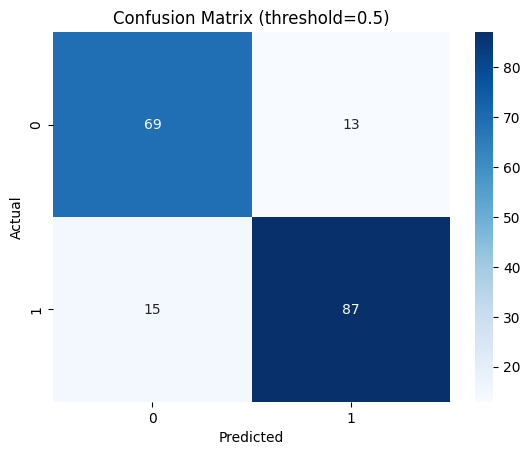

In [46]:
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_default = (proba_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_default)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

### Threshold optimization

In [47]:
thresholds = np.arange(0.20, 0.80, 0.05)
rows = []
for t in thresholds:
    pred_t = (proba_test >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t),
    })
thresh_df = pd.DataFrame(rows)
thresh_df

,threshold,precision,recall,f1
0,0.20,0.816667,0.960784,0.882883
1,0.25,0.822034,0.950980,0.881818
2,0.30,0.818966,0.931373,0.871560
3,0.35,0.846847,0.921569,0.882629
4,0.40,0.867925,0.901961,0.884615
5,0.45,0.865385,0.882353,0.873786
6,0.50,0.870000,0.852941,0.861386
7,0.55,0.902174,0.813725,0.855670
8,0.60,0.940476,0.774510,0.849462
9,0.65,0.948052,0.715686,0.815642


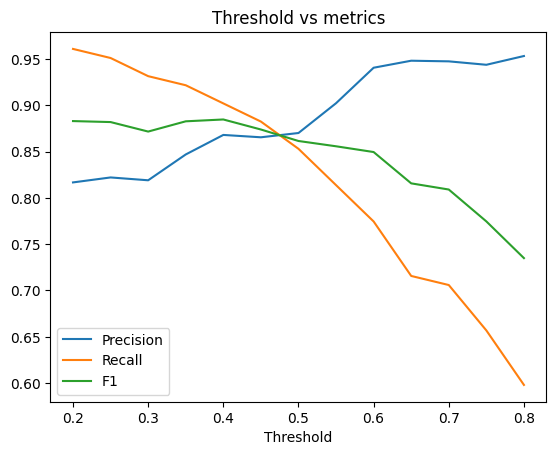

In [48]:
plt.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision")
plt.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall")
plt.plot(thresh_df["threshold"], thresh_df["f1"], label="F1")
plt.xlabel("Threshold"); plt.legend(); plt.title("Threshold vs metrics")
plt.show()

Threshold must be re-checked **after** calibration below — a threshold picked on uncalibrated scores can land in the wrong place once probabilities shift.

## Trustworthiness

### Probability calibration

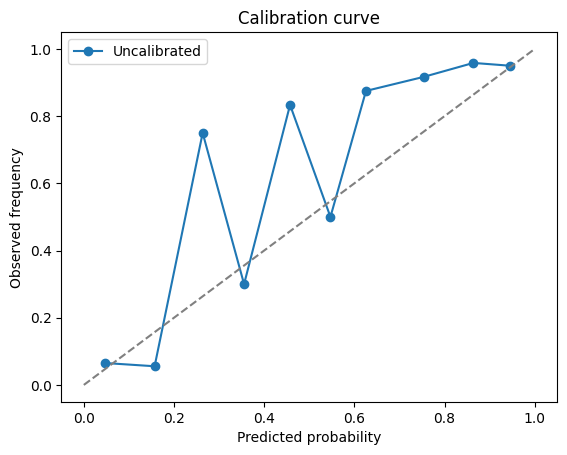

Brier score (uncalibrated): 0.10491959750652313


In [49]:
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
plt.plot(prob_pred, prob_true, marker="o", label="Uncalibrated")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.legend(); plt.title("Calibration curve")
plt.show()
print("Brier score (uncalibrated):", brier_score_loss(y_test, proba_test))

Brier score (calibrated): 0.10220157807447083


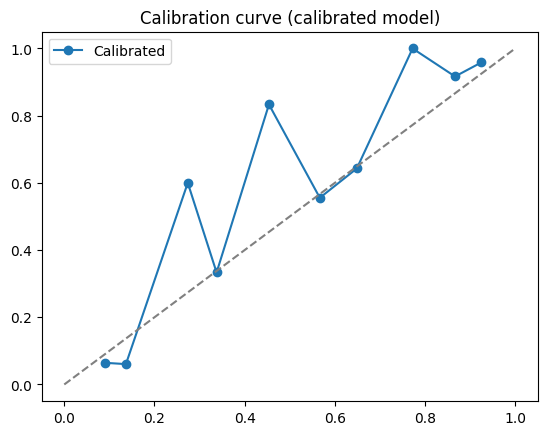

In [50]:
calibrated_model = CalibratedClassifierCV(best_model, method="sigmoid", cv=5)
calibrated_model.fit(X_train, y_train)
proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
print("Brier score (calibrated):", brier_score_loss(y_test, proba_cal))

prob_true_c, prob_pred_c = calibration_curve(y_test, proba_cal, n_bins=10)
plt.plot(prob_pred_c, prob_true_c, marker="o", label="Calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.legend(); plt.title("Calibration curve (calibrated model)")
plt.show()

### Threshold sweep on calibrated scores

In [51]:
rows = []
for t in np.arange(0.20, 0.80, 0.05):
    pred_t = (proba_cal >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t),
    })
thresh_df_cal = pd.DataFrame(rows)
thresh_df_cal

,threshold,precision,recall,f1
0,0.20,0.816667,0.960784,0.882883
1,0.25,0.823529,0.960784,0.886878
2,0.30,0.826087,0.931373,0.875576
3,0.35,0.854545,0.921569,0.886792
4,0.40,0.867925,0.901961,0.884615
5,0.45,0.873786,0.882353,0.878049
6,0.50,0.870000,0.852941,0.861386
7,0.55,0.887755,0.852941,0.870000
8,0.60,0.901099,0.803922,0.849741
9,0.65,0.928571,0.764706,0.838710


In [52]:
CHOSEN_THRESHOLD = 0.50  # set from thresh_df_cal above
print("Chosen threshold:", CHOSEN_THRESHOLD)

Chosen threshold: 0.5


### Final evaluation, false positives / false negatives

Accuracy: 0.8478260869565217
Precision: 0.87
Recall: 0.8529411764705882
F1: 0.8613861386138614
ROC-AUC: 0.9246771879483501
PR-AUC: 0.9319222671596605

TN=69  FP=13  FN=15  TP=87


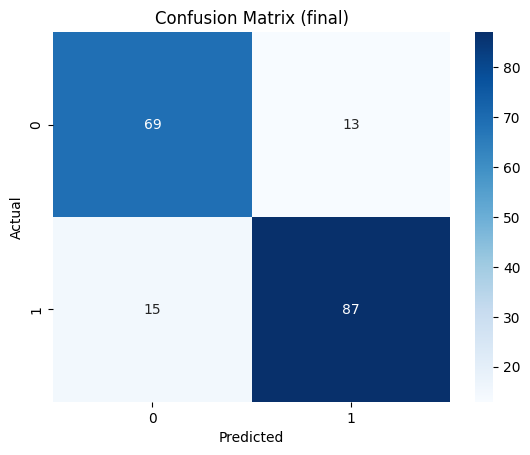

In [53]:
final_pred = (proba_cal >= CHOSEN_THRESHOLD).astype(int)

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("ROC-AUC:", roc_auc_score(y_test, proba_cal))
print("PR-AUC:", average_precision_score(y_test, proba_cal))

cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (final)")
plt.show()

Unlike Stage 1, this is a confirmatory clinical model on real measurements (not self-reported lifestyle), so a more balanced precision/recall tradeoff is reasonable here rather than recall-at-all-costs.

### Feature importance / SHAP

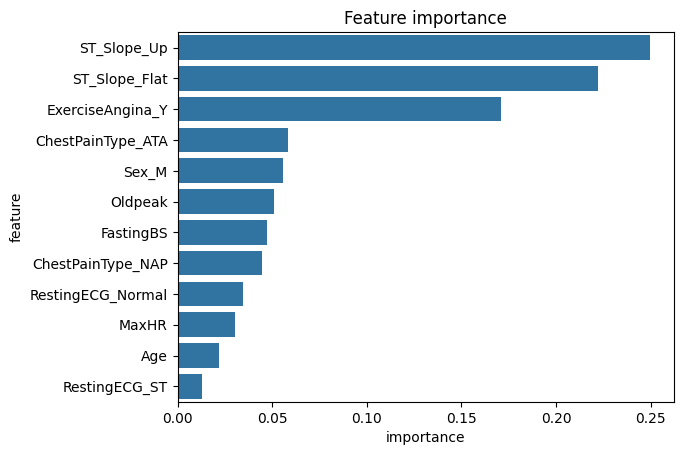

In [54]:
clf = best_model.named_steps["clf"]
feature_names = numeric_cols + [c for c in feature_cols if c not in numeric_cols]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        "importance", ascending=False)
    sns.barplot(x="importance", y="feature", data=imp_df)
    plt.title("Feature importance")
    plt.show()

In [55]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"feature": X_test.columns, "importance": perm.importances_mean}
                        ).sort_values("importance", ascending=False)
perm_df

,feature,importance
4,Sex_M,0.023649
5,ChestPainType_ATA,0.022561
11,ST_Slope_Up,0.021078
3,FastingBS,0.016320
9,ExerciseAngina_Y,0.011526
2,Oldpeak,0.008764
10,ST_Slope_Flat,0.008537
1,MaxHR,0.004699
6,ChestPainType_NAP,0.002499
0,Age,0.001650


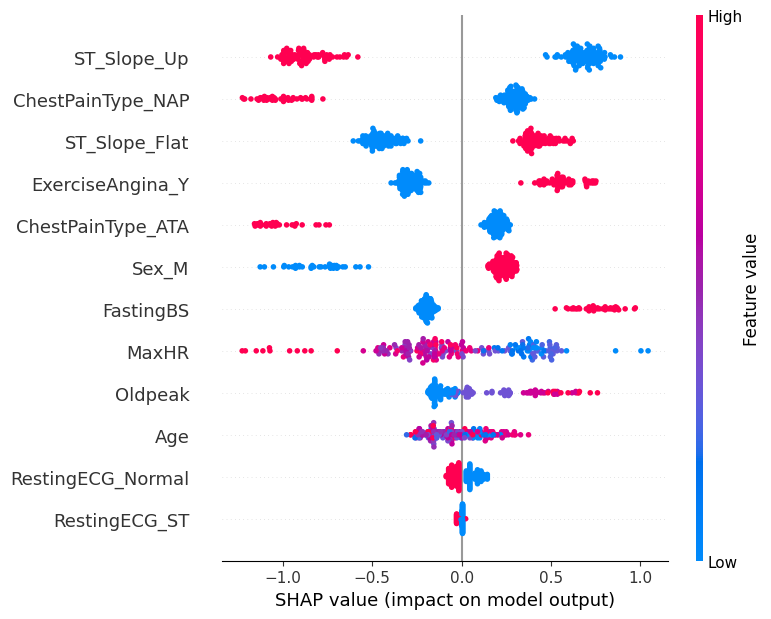

In [56]:
import shap

X_test_transformed = best_model.named_steps["prep"].transform(X_test)

if isinstance(clf, (RandomForestClassifier, XGBClassifier)):
    explainer = shap.TreeExplainer(clf)
else:
    explainer = shap.LinearExplainer(clf, best_model.named_steps["prep"].transform(X_train))

shap_values = explainer.shap_values(X_test_transformed)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

### Robustness across seeds

In [57]:
seed_scores = []
for seed in [0, 1, 42, 123, 2024]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    m = Pipeline([("prep", preprocessor), ("clf", best_model.named_steps["clf"])])
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    seed_scores.append({"seed": seed, "roc_auc": roc_auc_score(yte, p),
                         "pr_auc": average_precision_score(yte, p)})
seed_df = pd.DataFrame(seed_scores)
seed_df

,seed,roc_auc,pr_auc
0,0,0.949904,0.961559
1,1,0.890005,0.901557
2,42,0.923482,0.930849
3,123,0.918819,0.912629
4,2024,0.936514,0.947279


### Robustness across subgroups (Sex)

In [58]:
def subgroup_report(group_col, X_ref):
    rows = []
    for val, idx in X_ref.groupby(group_col).groups.items():
        yt = y_test.loc[idx]
        if yt.nunique() < 2:
            continue
        p = proba_cal[X_ref.index.get_indexer(idx)]
        rows.append({group_col: val, "n": len(idx), "positive_rate": yt.mean(),
                      "roc_auc": roc_auc_score(yt, p), "pr_auc": average_precision_score(yt, p)})
    return pd.DataFrame(rows)

subgroup_report("Sex_M", X_test)

,Sex_M,n,positive_rate,roc_auc,pr_auc
0,0,38,0.157895,0.880208,0.666071
1,1,146,0.657534,0.910833,0.942145


Not diagnostic: this model estimates risk from clinical measurements, it does not replace a cardiologist's evaluation. Reported probabilities are calibrated model scores, not certainty of disease.

## Final Clinical Model — Save Artifacts

In [60]:
import os
import json
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(calibrated_model, "models/clinical_model.pkl")
joblib.dump(preprocessor, "models/clinical_preprocessor.pkl")

clinical_metadata = {
    "model_version": "v1.0",
    "stage": "clinical_prediction",
    "random_state": RANDOM_STATE,
    "features": feature_cols,
    "target": "HeartDisease",
    "threshold": float(CHOSEN_THRESHOLD),
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, final_pred)),
        "precision": float(precision_score(y_test, final_pred)),
        "recall": float(recall_score(y_test, final_pred)),
        "f1": float(f1_score(y_test, final_pred)),
        "roc_auc": float(roc_auc_score(y_test, proba_cal)),
        "pr_auc": float(average_precision_score(y_test, proba_cal)),
        "brier_score": float(brier_score_loss(y_test, proba_cal)),
    },
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
}

with open("models/clinical_metadata.json", "w") as f:
    json.dump(clinical_metadata, f, indent=2)

print("Saved clinical model artifacts successfully.")
clinical_metadata

Saved clinical model artifacts successfully.


{'model_version': 'v1.0',
 'stage': 'clinical_prediction',
 'random_state': 42,
 'features': ['Age',
  'MaxHR',
  'Oldpeak',
  'FastingBS',
  'Sex_M',
  'ChestPainType_ATA',
  'ChestPainType_NAP',
  'RestingECG_Normal',
  'RestingECG_ST',
  'ExerciseAngina_Y',
  'ST_Slope_Flat',
  'ST_Slope_Up'],
 'target': 'HeartDisease',
 'threshold': 0.5,
 'test_metrics': {'accuracy': 0.8478260869565217,
  'precision': 0.87,
  'recall': 0.8529411764705882,
  'f1': 0.8613861386138614,
  'roc_auc': 0.9246771879483501,
  'pr_auc': 0.9319222671596605,
  'brier_score': 0.10220157807447083},
 'training_rows': 734,
 'test_rows': 184}